In [51]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from dataclasses import dataclass
from pathlib import Path
from bs4 import BeautifulSoup
from tqdm import tqdm
from PyPDF2 import PdfReader
import plotly.express as px
from matplotlib.ticker import FuncFormatter

In [2]:
# Set plot style
sns.set(style="whitegrid")

In [40]:
# Load your dataset
dfb = pd.read_csv('../data/clean-data/data_breakfast.csv', low_memory=False)

dfb.head()

,school_name,date,identifier,name,planned_reimbursable,planned_non-reimbursable,planned_total,offered,served_reimbursable,served_non-reimbursable,served_total,served_cost,discarded_total,discarded_percent_of_offered,discarded_cost,subtotal_cost,left_over_total,left_over_percent_of_offered,left_over_cost,production_cost_total
0,Aldrin Elementary,2025-05-01,20001,1% White Milk(Each),33,0,33,37,34,0,34,$12.24,0,0.00%,$0.00,$12.24,3,8.11%,$1.08,$13.32
1,Aldrin Elementary,2025-05-01,30008,Apple Juice(Each),43,0,43,55,50,0,50,$8.50,0,0.00%,$0.00,$8.50,5,9.09%,$0.85,$9.35
2,Aldrin Elementary,2025-05-01,60089,Assorted Cereal(Cereal Cup),0,0,0,10,4,0,4,$2.36,0,0.00%,$0.00,$2.36,6,60.00%,$3.54,$5.90
3,Aldrin Elementary,2025-05-01,30004,Blueberry Chex Cereal(Each),11,0,11,10,8,0,8,$4.72,0,0.00%,$0.00,$4.72,2,20.00%,$1.18,$5.90
4,Aldrin Elementary,2025-05-01,30068,Chilled Peaches(1/2 cup (drained)),13,0,13,12,11,0,11,$5.61,0,0.00%,$0.00,$5.61,1,8.33%,$0.51,$6.12


In [41]:
# file containing additional information
additional = pd.read_csv('../data/preprocessed-data/data_breakfast_with_coordinates.csv', low_memory=False)

# Convert column names to lowercase
additional.columns = additional.columns.str.lower()

additional.columns

Index(['school_name', 'date', 'identifier', 'name', 'planned_reimbursable',
       'planned_non-reimbursable', 'planned_total', 'offered_reimbursable',
       'offered_non-reimbursable', 'offered_total', 'served_reimbursable',
       'served_non-reimbursable', 'served_total', 'discarded_total',
       'discarded_cost', 'subtotal_cost', 'left_over_total',
       'left_over_percent_of_offered', 'left_over_cost',
       'production_cost_total', 'original_school_name_csv',
       'normalized_school_name_csv', 'mapped_normalized_name', 'school name',
       'school id', 'distribution kitchen (dk)', 'fns area', 'level',
       'fcps region', 'cep schools', 'original_school_name_excel',
       'normalized_school_name_excel', 'address', 'zipcode', 'latitude',
       'longitude'],
      dtype='object')

In [42]:
# columns to add in
add_subset = additional[["school_name", "school id", "level","fcps region","address","zipcode","latitude","longitude"]]

# delete duplicates
add_subset = add_subset.drop_duplicates(subset=['school_name'])

# Merge on 'School Name'
dfb = pd.merge(dfb, add_subset, on="school_name", how="left")

dfb.head()

,school_name,date,identifier,name,planned_reimbursable,planned_non-reimbursable,planned_total,offered,served_reimbursable,served_non-reimbursable,...,left_over_percent_of_offered,left_over_cost,production_cost_total,school id,level,fcps region,address,zipcode,latitude,longitude
0,Aldrin Elementary,2025-05-01,20001,1% White Milk(Each),33,0,33,37,34,0,...,8.11%,$1.08,$13.32,305,ES,Region 1,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
1,Aldrin Elementary,2025-05-01,30008,Apple Juice(Each),43,0,43,55,50,0,...,9.09%,$0.85,$9.35,305,ES,Region 1,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
2,Aldrin Elementary,2025-05-01,60089,Assorted Cereal(Cereal Cup),0,0,0,10,4,0,...,60.00%,$3.54,$5.90,305,ES,Region 1,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
3,Aldrin Elementary,2025-05-01,30004,Blueberry Chex Cereal(Each),11,0,11,10,8,0,...,20.00%,$1.18,$5.90,305,ES,Region 1,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
4,Aldrin Elementary,2025-05-01,30068,Chilled Peaches(1/2 cup (drained)),13,0,13,12,11,0,...,8.33%,$0.51,$6.12,305,ES,Region 1,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806


In [43]:
# Show basic info
print("Shape of dataset:", dfb.shape)
print("\nData types:\n", dfb.dtypes)

Shape of dataset: (55646, 27)

Data types:
 school_name                      object
date                             object
identifier                       object
name                             object
planned_reimbursable              int64
planned_non-reimbursable          int64
planned_total                     int64
offered                           int64
served_reimbursable               int64
served_non-reimbursable           int64
served_total                      int64
served_cost                      object
discarded_total                   int64
discarded_percent_of_offered     object
discarded_cost                   object
subtotal_cost                    object
left_over_total                   int64
left_over_percent_of_offered     object
left_over_cost                   object
production_cost_total            object
school id                         int64
level                            object
fcps region                      object
address                          obj

In [44]:
cols_to_convert = ["production_cost_total", "served_cost","discarded_percent_of_offered","discarded_cost","subtotal_cost","left_over_percent_of_offered","left_over_cost"]

for col in cols_to_convert:
    dfb[col] = (
        dfb[col]
        .astype(str)                           # ensure values are strings
        .str.replace(r"[\$,]", "", regex=True) # remove $ and commas
        .str.strip()                           # remove spaces
    )
    dfb[col] = pd.to_numeric(dfb[col], errors="coerce")  # convert to numbers

print("\nData types:\n", dfb.dtypes)


Data types:
 school_name                      object
date                             object
identifier                       object
name                             object
planned_reimbursable              int64
planned_non-reimbursable          int64
planned_total                     int64
offered                           int64
served_reimbursable               int64
served_non-reimbursable           int64
served_total                      int64
served_cost                     float64
discarded_total                   int64
discarded_percent_of_offered    float64
discarded_cost                  float64
subtotal_cost                   float64
left_over_total                   int64
left_over_percent_of_offered    float64
left_over_cost                  float64
production_cost_total           float64
school id                         int64
level                            object
fcps region                      object
address                          object
zipcode                   

In [45]:
# show statistics
dfb.describe()

,planned_reimbursable,planned_non-reimbursable,planned_total,offered,served_reimbursable,served_non-reimbursable,served_total,served_cost,discarded_total,discarded_percent_of_offered,discarded_cost,subtotal_cost,left_over_total,left_over_percent_of_offered,left_over_cost,production_cost_total,school id,zipcode,latitude,longitude
count,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,0.0,55646.000000,55646.000000,55646.000000,0.0,55646.000000,55646.000000,55646.000000,43954.000000,55646.000000,55646.000000
mean,33.435431,0.081300,33.516731,45.235812,35.404432,0.507817,35.912249,11.817301,0.129282,NaN,0.062303,11.879604,9.195450,NaN,3.051450,14.930780,231.066887,21685.291418,38.845863,-77.254698
std,63.312415,1.042007,63.355922,68.060557,58.877480,3.289844,59.028820,17.287661,1.021627,NaN,0.492206,17.304935,21.275619,NaN,6.525665,20.051599,187.733059,829.938842,0.074291,0.106620
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,17.000000,20120.000000,38.684824,-77.485556
25%,2.000000,0.000000,2.000000,10.000000,5.000000,0.000000,6.000000,2.360000,0.000000,NaN,0.000000,2.380000,0.000000,NaN,0.000000,4.080000,106.000000,22003.000000,38.790261,-77.337806
50%,14.000000,0.000000,14.000000,24.000000,16.000000,0.000000,17.000000,6.110000,0.000000,NaN,0.000000,6.120000,3.000000,NaN,1.160000,8.580000,212.000000,22042.000000,38.843720,-77.241318
75%,40.000000,0.000000,40.000000,51.000000,40.000000,0.000000,41.000000,14.110000,0.000000,NaN,0.000000,14.160000,10.000000,NaN,3.540000,17.700000,334.000000,22152.000000,38.898639,-77.176149
max,4561.000000,63.000000,4561.000000,2245.000000,2216.000000,165.000000,2216.000000,731.280000,53.000000,NaN,31.270000,731.280000,985.000000,NaN,256.320000,740.850000,2459.000000,23305.000000,39.041851,-77.047536


In [46]:
# Check for missing values
print("\nMissing values:\n", dfb.isnull().sum())


Missing values:
 school_name                         0
date                                0
identifier                          0
name                                0
planned_reimbursable                0
planned_non-reimbursable            0
planned_total                       0
offered                             0
served_reimbursable                 0
served_non-reimbursable             0
served_total                        0
served_cost                         0
discarded_total                     0
discarded_percent_of_offered    55646
discarded_cost                      0
subtotal_cost                       0
left_over_total                     0
left_over_percent_of_offered    55646
left_over_cost                      0
production_cost_total               0
school id                           0
level                               0
fcps region                         0
address                             0
zipcode                         11692
latitude                        

In [47]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfb.duplicated().sum())


Number of duplicate rows: 0


In [48]:
# overview look at food names
food_cat = dfb.groupby('name')['planned_total'].sum()

summary_b = food_cat.sort_values(ascending=False)
sumb_10 = summary_b.head(10
)
print(sumb_10)

name
Apple Juice(Each)                                     453973
Orange Tangerine Juice(Each)                          248470
1% White Milk(Each)                                   211190
Mini Maple Pancakes(Package)                          140160
Red Delicious Apple(Each - serving)                    89769
Honey Cheerios Cereal(Each)                            76478
Cinnamon Toast Crunch Cereal, 25% Less Sugar(Each)     71307
Cinnamon Chex Cereal(Each)                             67403
Fat Free White Milk(Each)                              64173
Blueberry Chex Cereal(Each)                            59862
Name: planned_total, dtype: int64


In [71]:
# Current working directory
cwd = os.getcwd()  # Usually the folder where your notebook is running

# Define the results folder relative to the notebook
results_folder = os.path.join(cwd, "..\\data\\results\\EDA")

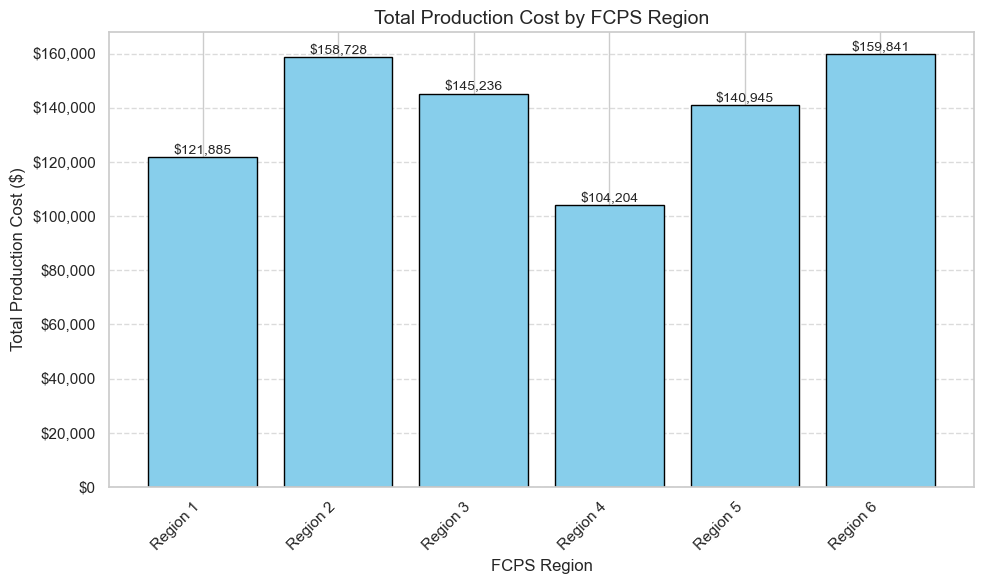

In [72]:
# Define desired order of regions
region_order = [f"Region {i}" for i in range(1, 7)]

# Group by region and sum production cost
region_costs = (
    dfb.groupby("fcps region")["production_cost_total"]
    .sum()
    .reindex(region_order)  # enforce custom order
)

# Create bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(region_costs.index, region_costs.values, color="skyblue", edgecolor="black")

# Add title and labels
plt.title("Total Production Cost by FCPS Region", fontsize=14)
plt.xlabel("FCPS Region", fontsize=12)
plt.ylabel("Total Production Cost ($)", fontsize=12)

# Format y-axis as dollars
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Rotate x-labels for clarity
plt.xticks(rotation=45, ha="right")

# Optional: add value labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "production_cost_by_region.png"), dpi=300, bbox_inches='tight')
plt.show()


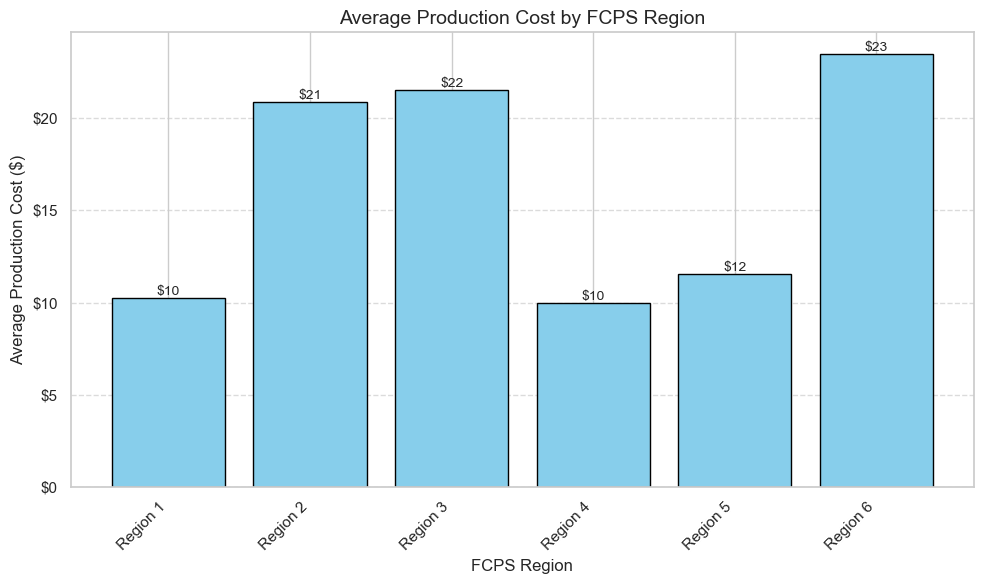

In [ ]:
# Define desired order of regions
region_order = [f"Region {i}" for i in range(1, 7)]

# Group by region and calculate average production cost
avg_region_costs = (
    dfb.groupby("fcps region")["production_cost_total"]
    .mean()
    .reindex(region_order)
)

# Create bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_region_costs.index, avg_region_costs.values, color="skyblue", edgecolor="black")

# Add title and labels
plt.title("Average Production Cost by FCPS Region", fontsize=14)
plt.xlabel("FCPS Region", fontsize=12)
plt.ylabel("Average Production Cost ($)", fontsize=12)

# Format y-axis as dollars
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add value labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "avg_production_cost_by_region.png"), dpi=300, bbox_inches='tight')
plt.show()

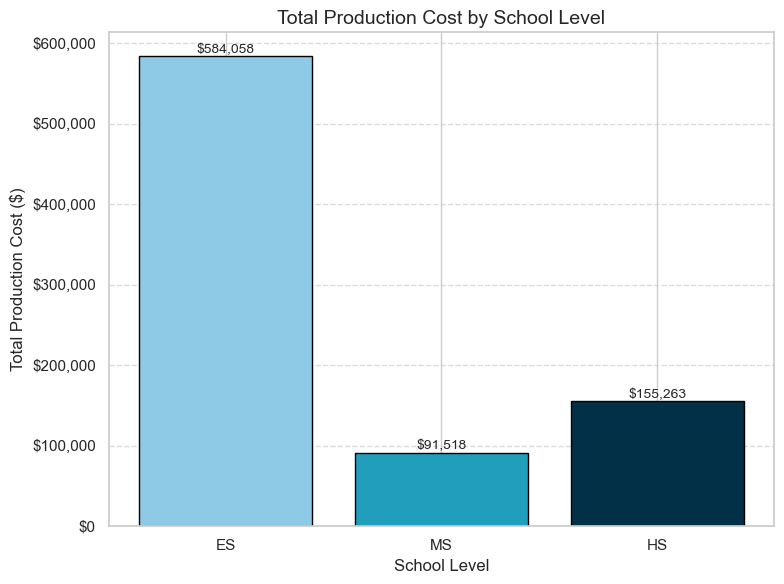

In [ ]:
# Define desired order for levels
level_order = ["ES", "MS", "HS"]

# Group by level and sum production cost
level_costs = (
    dfb.groupby("level")["production_cost_total"]
    .sum()
    .reindex(level_order)
)

# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(level_costs.index, level_costs.values, color=["#8ecae6", "#219ebc", "#023047"], edgecolor="black")

# Add title and labels
plt.title("Total Production Cost by School Level", fontsize=14)
plt.xlabel("School Level", fontsize=12)
plt.ylabel("Total Production Cost ($)", fontsize=12)

# Format y-axis as dollars with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Optional: add grid for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "production_cost_by_level.png"), dpi=300, bbox_inches='tight')
plt.show()

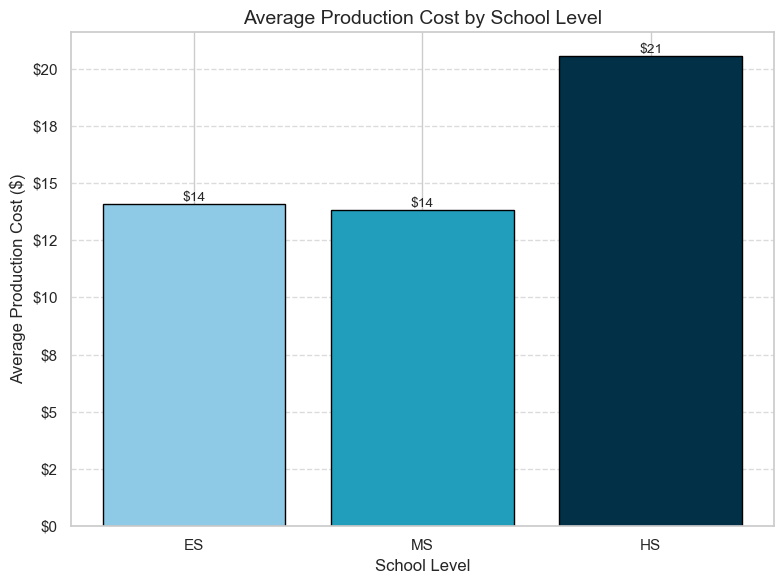

In [ ]:
# Define desired order for levels
level_order = ["ES", "MS", "HS"]

# Group by level and calculate average production cost
avg_level_costs = (
    dfb.groupby("level")["production_cost_total"]
    .mean()
    .reindex(level_order)
)

# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(level_order, avg_level_costs.values, color=["#8ecae6", "#219ebc", "#023047"], edgecolor="black")

# Add title and labels
plt.title("Average Production Cost by School Level", fontsize=14)
plt.xlabel("School Level", fontsize=12)
plt.ylabel("Average Production Cost ($)", fontsize=12)

# Format y-axis as dollars
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add value labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "avg_production_cost_by_level.png"), dpi=300, bbox_inches='tight')
plt.show()